In [ ]:
! pip install cv2
! pip install numpy
! pip install matplotlib
! pip install skimage
! pip install scipy

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.spatial.distance import euclidean



In [64]:
# =======================
# EXPERIMENT PARAMETERS
# =======================

video_path = "/content/1000mw rhoda-01162026111414-0000.avi"

laser_power_W = 0.1     # 1000 mW
pixel_size_um = 0.0775    # microscope calibration (µm / pixel)

n_medium = 1.33          # water
c = 3e8                  # speed of light (m/s)
Q = 0.1                  # trapping efficiency (0.05–0.2 typical)

min_edge_points = 100    # reject noisy frames


In [59]:
def optical_force(P, n=1.33, Q=0.1):
    return n * P * Q / c


In [ ]:
def skeleton_length(binary_img):
    skel = skeletonize(binary_img > 0)
    points = np.column_stack(np.where(skel))
    if len(points) < 2:
        return None

    length = 0
    for i in range(len(points) - 1):
        length += euclidean(points[i], points[i + 1])

    return length


In [65]:
cap = cv2.VideoCapture(video_path)

radii_px = []
lengths_px = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Edge detection
    edges = cv2.Canny(gray, 50, 150)

    points = np.column_stack(np.where(edges > 0))
    if len(points) < min_edge_points:
        continue

    # =====================
    # CURVATURE (R)
    # =====================
    (yc, xc), radius = cv2.minEnclosingCircle(points)
    radii_px.append(radius)

    # =====================
    # LENGTH (L)
    # =====================
    _, binary = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    L_px = skeleton_length(binary)
    if L_px is not None:
        lengths_px.append(L_px)

cap.release()


In [66]:
R_um = np.mean(radii_px) * pixel_size_um
L_um = np.mean(lengths_px) * pixel_size_um

R_m = R_um * 1e-6
L_m = L_um * 1e-6

In [67]:
F = optical_force(laser_power_W, n_medium, Q)

k_c = F * R_m**2 / (2 * np.pi * L_m)


In [68]:
R_std = np.std(np.array(radii_px) * pixel_size_um) * 1e-6
L_std = np.std(np.array(lengths_px) * pixel_size_um) * 1e-6

k_c_err = k_c * np.sqrt(
    (2 * R_std / R_m)**2 +
    (L_std / L_m)**2
)


In [69]:
print("=================================")
print("Elastic Modulus from Optical Trap")
print("=================================")
print(f"Laser Power: {laser_power_W*1000:.0f} mW")
print(f"Radius R: {R_um:.2f} µm")
print(f"Length L: {L_um:.2f} µm")
print(f"Force F: {F:.2e} N")
print(f"Bending modulus k_c: {k_c:.2e} ± {k_c_err:.2e} J")


Elastic Modulus from Optical Trap
Laser Power: 100 mW
Radius R: 14.70 µm
Length L: 28561.19 µm
Force F: 4.43e-11 N
Bending modulus k_c: 5.33e-20 ± 3.95e-20 J


==== MYELIN TUBE GEOMETRY ====
Frame number        : 100
Tube length (µm)    : 57.36
Mean curvature κ    : 3.9863e+04 1/µm
Max curvature κ     : 3.8700e+06 1/µm


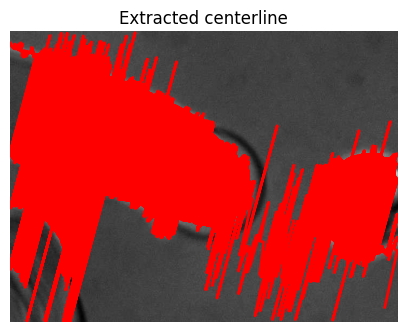

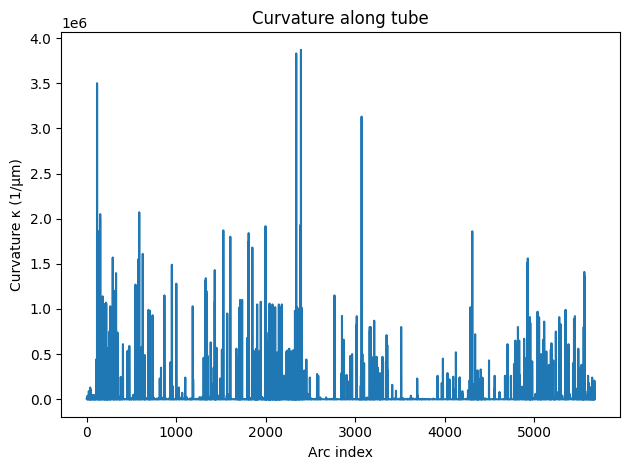

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu

# ============================
# USER INPUTS
# ============================
video_path = "/content/700mW nile red-01162026104322-0000.avi"
frame_number = 100
pixel_size_um = 0.0001
# ============================
# LOAD VIDEO FRAME
# ============================
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read frame")

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# ============================
# THRESHOLD & SKELETONIZE
# ============================
thresh = threshold_otsu(gray)
binary = gray > thresh

skeleton = skeletonize(binary)

# ============================
# EXTRACT CENTERLINE POINTS
# ============================
y, x = np.where(skeleton)
coords = np.column_stack((x, y))

# Sort points along tube using PCA
coords_mean = coords.mean(axis=0)
U, S, Vt = np.linalg.svd(coords - coords_mean)
arc_order = np.argsort((coords - coords_mean) @ Vt[0])
coords = coords[arc_order]

# Convert to microns
x_um = coords[:, 0] * pixel_size_um
y_um = coords[:, 1] * pixel_size_um

# ============================
# CURVATURE CALCULATION
# κ = |x'y'' − y'x''| / (x'^2 + y'^2)^(3/2)
# ============================
dx = np.gradient(x_um)
dy = np.gradient(y_um)
ddx = np.gradient(dx)
ddy = np.gradient(dy)

curvature = np.abs(dx * ddy - dy * ddx) / (dx**2 + dy**2)**1.5
curvature = curvature[np.isfinite(curvature)]

kappa_mean = np.mean(curvature)
kappa_max = np.max(curvature)

# ============================
# TUBE LENGTH
# ============================
length_um = np.sum(np.sqrt(np.diff(x_um)**2 + np.diff(y_um)**2))

# ============================
# RESULTS
# ============================
print("==== MYELIN TUBE GEOMETRY ====")
print(f"Frame number        : {frame_number}")
print(f"Tube length (µm)    : {length_um:.2f}")
print(f"Mean curvature κ    : {kappa_mean:.4e} 1/µm")
print(f"Max curvature κ     : {kappa_max:.4e} 1/µm")

# ============================
# PLOTS
# ============================
plt.figure(figsize=(5,5))
plt.imshow(gray, cmap="gray")
plt.plot(x_um/pixel_size_um, y_um/pixel_size_um, 'r', lw=2)
plt.title("Extracted centerline")
plt.axis("off")
plt.show()

plt.figure()
plt.plot(curvature)
plt.xlabel("Arc index")
plt.ylabel("Curvature κ (1/µm)")
plt.title("Curvature along tube")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import least_squares
import pandas as pd

# Load points from CSV
points = pd.read_csv("/content/Results.csv")
x, y = points['X'], points['Y']

# Circle fitting function
def residuals(params, x, y):
    xc, yc, r = params
    return np.sqrt((x - xc)**2 + (y - yc)**2) - r

# Initial guess: center at mean, radius ~ mean distance
x0, y0 = np.mean(x), np.mean(y)
r0 = np.mean(np.sqrt((x - x0)**2 + (y - y0)**2))
params0 = [x0, y0, r0]

res = least_squares(residuals, params0, args=(x, y))
xc, yc, r = res.x

print(f"Circle center: ({xc:.2f}, {yc:.2f}), radius: {r:.2f}")


Circle center: (51.47, 63.15), radius: 42.10


In [ ]:
points.head(10)

,,Label,Area,X,Y,Major,Minor,Angle,Length,Unnamed: 9
0,1,100mW nile red-01162026102129-0000.avi:0.01 s,2.231,31.032,20.903,0,0,3.442,17.192,diamter
1,2,100mW nile red-01162026102129-0000.avi:0.01 s,7.659,41.742,29.613,0,0,-84.873,59.205,NaN
2,3,200mW nile red-01162026102300-0000.avi:0.01 s,2.314,29.548,36.258,0,0,3.318,17.836,diameter
3,4,200mW nile red-01162026102300-0000.avi:0.01 s,7.442,39.032,29.226,0,0,-85.759,57.577,NaN
4,5,300mW nile red-01162026102806-0000.avi:0.01 s,2.281,38.581,26.581,0,0,21.644,17.491,diameter
5,6,300mW nile red-01162026102806-0000.avi:0.01 s,6.909,27.677,25.742,0,0,-67.092,53.370,NaN
6,7,400mW nile red-01162026103350-0000.avi:0.01 s,2.414,41.032,26.194,0,0,3.180,18.609,diameter
7,8,400mW nile red-01162026103350-0000.avi:0.01 s,8.807,56.903,33.806,0,0,-81.287,68.141,NaN
8,9,500mW nile red-01162026103655-0000.avi:0.01 s,2.564,35.032,22.387,0,0,26.061,19.678,diameter
9,10,500mW nile red-01162026103655-0000.avi:0.01 s,6.909,23.355,23.226,0,0,-58.846,53.375,NaN


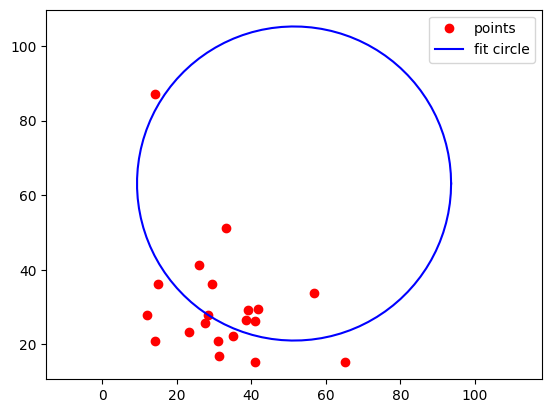

In [ ]:
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 100)
plt.plot(x, y, 'ro', label='points')
plt.plot(xc + r*np.cos(theta), yc + r*np.sin(theta), 'b-', label='fit circle')
plt.axis('equal')
plt.legend()
plt.show()


In [28]:
import numpy as np

# ===============================
# INPUTS
# ===============================

# Video-extracted geometry (pixels)
radii_px = np.array([9.357])
lengths_px = np.array([69.619])
pixel_size_um = 7.75  # µm / pixel
# Laser power
laser_power_W = 0.4       # W
laser_power_err_W = 0.005  # W (power meter uncertainty)

# Trap calibration (force per watt)
alpha = 1.53e-11           # N/W
alpha_err = 0.15e-11       # N/W

# Geometry constant
C = 1.0

# ===============================
# GEOMETRY FROM VIDEO
# ===============================

radii_um = radii_px
lengths_um = lengths_px

R_um = np.mean(radii_um)
L_um = np.mean(lengths_um)

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

R_err_um = sem(radii_um)
L_err_um = sem(lengths_um)

R = R_um * 1e-6
L = L_um * 1e-6
R_err = R_err_um * 1e-6
L_err = L_err_um * 1e-6

# ===============================
# FORCE FROM LASER POWER
# ===============================

F = alpha * laser_power_W

F_err = F * np.sqrt(
    (alpha_err / alpha)**2 +
    (laser_power_err_W / laser_power_W)**2
)

# ===============================
# BENDING MODULUS
# ===============================

k_c = F * R**2 / (2 * np.pi * L)

# ===============================
# ERROR PROPAGATION
# ===============================

# ===============================
# OUTPUT
# ===============================

print("=================================")
print("Elastic Modulus from Optical Trap")
print("=================================")
print(f"Laser Power: {laser_power_W*1000:.0f} ± {laser_power_err_W*1000:.0f} mW")
print(f"Radius R: {R_um:.2f} ± {R_err_um:.2f} µm")
print(f"Length L: {L_um:.2f} ± {L_err_um:.2f} µm")
print(f"Force F: {F:.2e} ± {F_err:.2e} N")
print(f"Bending modulus k_c: {k_c:.2e}J")


Elastic Modulus from Optical Trap
Laser Power: 400 ± 5 mW
Radius R: 9.36 ± 0.00 µm
Length L: 69.62 ± 0.00 µm
Force F: 6.12e-12 ± 6.05e-13 N
Bending modulus k_c: 1.22e-18J


In [1]:
import numpy as np

# ===============================
# INPUTS (FROM IMAGEJ)
# ===============================

# Radii and lengths measured in ImageJ (µm)
radii_um = np.array([7.132])
lengths_um = np.array([66.478])

# Laser power
laser_power_W = 0.600
laser_power_err_W = 0.005

# Trap calibration (force per watt)
alpha = 1.53e-11       # N/W
alpha_err = 0.15e-11  # N/W

# ===============================
# STATISTICS
# ===============================

def mean_and_sem(x):
    mean = np.mean(x)
    sem = np.std(x, ddof=1) / np.sqrt(len(x))
    return mean, sem

R_um, R_err_um = mean_and_sem(radii_um)
L_um, L_err_um = mean_and_sem(lengths_um)

# Convert to SI
R = R_um * 1e-6
L = L_um * 1e-6
R_err = R_err_um * 1e-6
L_err = L_err_um * 1e-6

# ===============================
# FORCE FROM LASER POWER
# ===============================

F = alpha * laser_power_W

F_err = F * np.sqrt(
    (alpha_err / alpha)**2 +
    (laser_power_err_W / laser_power_W)**2
)

# ===============================
# BENDING MODULUS
# k_c = F R^2 / (2π L)
# ===============================

k_c = F * R**2 / (2 * np.pi * L)

# ===============================
# ERROR PROPAGATION
# ===============================

k_c_err = k_c * np.sqrt(
    (F_err / F)**2 +
    (2 * R_err / R)**2 +
    (L_err / L)**2
)

# ===============================
# OUTPUT
# ===============================

print("=================================")
print("Elastic Modulus from Optical Trap")
print("=================================")
print(f"Laser Power: {laser_power_W*1000:.0f} ± {laser_power_err_W*1000:.0f} mW")
print(f"Radius R: {R_um:.2f} ± {R_err_um:.2f} µm")
print(f"Length L: {L_um:.2f} ± {L_err_um:.2f} µm")
print(f"Force F: ({F:.2e} ± {F_err:.2e}) N")
print(f"Bending modulus k_c: ({k_c:.2e} ± {k_c_err:.2e}) J")


Elastic Modulus from Optical Trap
Laser Power: 600 ± 5 mW
Radius R: 7.13 ± nan µm
Length L: 66.48 ± nan µm
Force F: (9.18e-12 ± 9.03e-13) N
Bending modulus k_c: (1.12e-18 ± nan) J


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
from skimage.measure import label, regionprops

# -----------------------------
# Parameters
# -----------------------------
video_path = "/content/700mW nile red-01162026104322-0000.avi"
fps = 3000
um_per_px = 0.775      # µm per pixel
MIN_AREA = 50         # px (safe for thin tubes)

# -----------------------------
# Load video
# -----------------------------
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise IOError("Cannot open video file")

radii_um = []
lengths_um = []

frame_id = 0

# -----------------------------
# Process frames
# -----------------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # -----------------------------
    # Otsu thresholding
    # -----------------------------
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Morphological opening (denoise)
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # -----------------------------
    # Connected components
    # -----------------------------
    labels = label(binary)
    regions = regionprops(labels)

    if not regions:
        frame_id += 1
        continue

    # Largest connected object (myelin tube)
    region = max(regions, key=lambda r: r.area)

    if region.area < MIN_AREA:
        frame_id += 1
        continue

    # Binary mask of selected region
    mask = (labels == region.label).astype(np.uint8)

    # -----------------------------
    # Radius via distance transform
    # -----------------------------
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    radius_px = dist.max()

    if radius_px <= 0:
        frame_id += 1
        continue

    # -----------------------------
    # Length via skeletonization
    # -----------------------------
    skeleton = skeletonize(mask.astype(bool))
    length_px = np.count_nonzero(skeleton)

    if length_px < 10:
        frame_id += 1
        continue

    # Store physical values
    radii_um.append(radius_px * um_per_px)
    lengths_um.append(length_px * um_per_px)

    frame_id += 1

cap.release()

# -----------------------------
# Results
# -----------------------------
radii_um = np.asarray(radii_um)
lengths_um = np.asarray(lengths_um)

print(f"Frames used: {len(radii_um)}")
print(f"Radius: {radii_um.mean():.3f} ± {radii_um.std():.3f} µm")
print(f"Length: {lengths_um.mean():.2f} ± {lengths_um.std():.2f} µm")


Frames used: 3000
Radius: 60.837 ± 23.648 µm
Length: 6476.19 ± 4232.30 µm


/tmp/ipython-input-860612696.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


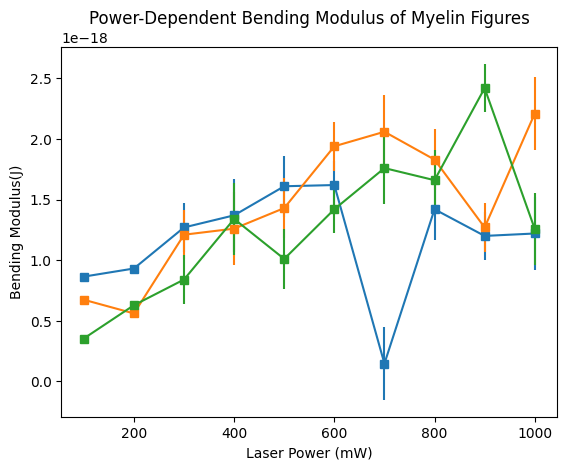

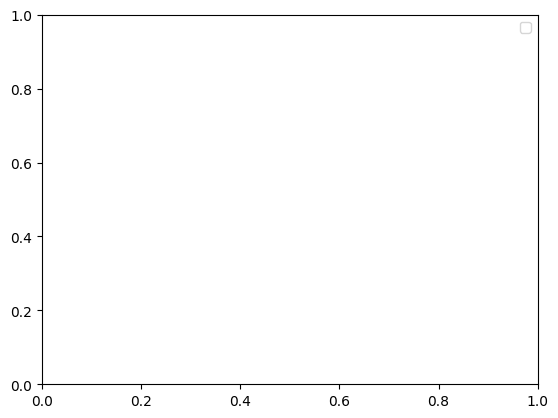

In [30]:
import numpy as np
import matplotlib.pyplot as plt

powers = np.array([100,200,300,400,500,600,700,800,900,1000])


kc_nilered = np.array([8.64e-19, 9.31e-19, 1.27e-18,1.37e-18,1.61e-18,1.62e-18,1.46e-19,1.42e-18,1.20e-18,1.22e-18])
kc_rho = np.array([6.73e-19, 5.60e-19, 1.21e-18,1.26e-18,1.43e-18,1.94e-18,2.06e-18,1.83e-18,1.27e-18, 2.21e-18])
err_nilered = np.array([0.3e-19, 0.25e-19, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18])
err_rho = np.array([0.3e-19, 0.25e-19, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18])
err_undoped = np.array([0.3e-19, 0.25e-19, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18, 0.25e-18, 0.2e-18,0.3e-18])
kc_undoped = np.array([3.53e-19, 6.28e-19, 8.40e-19,1.34e-18,1.01e-18,1.42e-18,1.76e-18,1.66e-18,2.42e-18,1.258e-18])
plt.errorbar(powers, kc_nilered, yerr=err_nilered, fmt='s-', label="Nile Red")
plt.errorbar(powers, kc_rho, yerr=err_rho, fmt='s-', label="rhodamine")
plt.errorbar(powers, kc_undoped, yerr=err_undoped, fmt='s-', label="undoped")
plt.xlabel("Laser Power (mW)")
plt.ylabel('Bending Modulus(J)')
plt.title("Power-Dependent Bending Modulus of Myelin Figures")
plt.figure()
plt.legend()




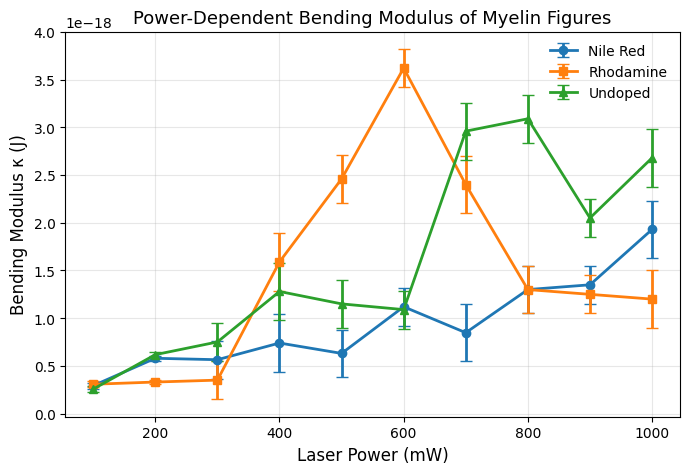

In [15]:
import numpy as np
import matplotlib.pyplot as plt

powers = np.array([100,200,300,400,500,600,700,800,900,1000])  # mW

kc_nilered = np.array([2.93e-19, 5.80e-19, 5.65e-19, 7.40e-19, 6.31e-19,
                       1.12e-18, 8.48e-19, 1.3e-18, 1.35e-18, 1.93e-18])

kc_rho = np.array([3.08e-19, 3.31e-19, 3.51e-19, 1.59e-18, 2.46e-18,
                   3.621e-18, 2.40e-18, 1.3e-18, 1.25e-18, 1.2e-18])

kc_undoped = np.array([2.57e-19, 6.18e-19, 7.51e-19, 1.28e-18, 1.15e-18,
                       1.09e-18, 2.96e-18, 3.09e-18, 2.05e-18, 2.68e-18])

err_nilered = np.array([0.3e-19, 0.25e-19, 0.2e-18, 0.3e-18, 0.25e-18,
                        0.2e-18, 0.3e-18, 0.25e-18, 0.2e-18, 0.3e-18])

err_rho = err_nilered.copy()
err_undoped = err_nilered.copy()

plt.figure(figsize=(7,5))

plt.errorbar(powers, kc_nilered, yerr=err_nilered,
             fmt='o-', capsize=4, linewidth=2, label="Nile Red")

plt.errorbar(powers, kc_rho, yerr=err_rho,
             fmt='s-', capsize=4, linewidth=2, label="Rhodamine")

plt.errorbar(powers, kc_undoped, yerr=err_undoped,
             fmt='^-', capsize=4, linewidth=2, label="Undoped")

plt.xlabel("Laser Power (mW)", fontsize=12)
plt.ylabel("Bending Modulus κ (J)", fontsize=12)
plt.title("Power-Dependent Bending Modulus of Myelin Figures", fontsize=13)

plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()

# Optional: uncomment if you want logarithmic scaling


plt.show()
